# Predictive Data Modeling 
##### notebook code (C) 2022-2026 Timothy James Becker
## CH3: Data Transformation/Visualization Supplement

(1) the official matplotlib api manual is [here](https://matplotlib.org/stable/api/)<br>

(2) the official pandas api manual is [here](https://pandas.pydata.org/docs/reference/index.html)<br>

(3) official numpy api manual is [here](https://numpy.org/doc/stable/reference/index.html)<br>

In [85]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

In [165]:
data   = pd.read_csv('NHANES.csv')
data

,SurveyYr,ID,Gender,Age,AgeDecade,AgeMonths,Race1,Race3,Education,MaritalStatus,...,AgeFirstMarij,RegularMarij,AgeRegMarij,HardDrugs,SexEver,SexAge,SexNumPartnLife,SexNumPartYear,SameSex,SexOrientation
0,2009_10,55829,female,28,20-29,343.0,White,NaN,CollegeGrad,Married,...,15.0,No,NaN,Yes,Yes,13.0,20.0,1.0,No,Heterosexual
1,2009_10,57112,male,14,10-19,170.0,White,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009_10,60232,male,80,NaN,NaN,White,NaN,8thGrade,Married,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009_10,59919,male,22,20-29,268.0,White,NaN,HighSchool,NeverMarried,...,10.0,Yes,10.0,Yes,Yes,18.0,3.0,1.0,No,Heterosexual
4,2009_10,56351,male,1,0-9,16.0,White,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2011_12,64065,male,46,40-49,NaN,White,White,SomeCollege,Married,...,NaN,No,NaN,No,Yes,17.0,7.0,1.0,No,Heterosexual
9996,2011_12,66189,male,47,40-49,NaN,Mexican,Mexican,9_11thGrade,Married,...,15.0,Yes,20.0,No,Yes,18.0,7.0,1.0,No,Heterosexual
9997,2011_12,63714,male,48,40-49,NaN,White,White,SomeCollege,Married,...,16.0,No,NaN,No,Yes,17.0,4.0,1.0,No,Heterosexual
9998,2011_12,68501,male,52,50-59,NaN,White,White,SomeCollege,Married,...,16.0,Yes,16.0,Yes,Yes,16.0,50.0,1.0,No,Heterosexual


#### Bar Plots (compare qualitative ratios)

In [87]:
counts = {}
for d in data[0:]['BMI']:
    if d in counts: counts[d] += 1
    else:           counts[d]  = 1
counts #pure python way to count

counts = data[0:]['BMI'].value_counts() #use builtin pandas histograms if you want

In [88]:
counts

BMI
23.2    53
25.6    52
26.4    46
23.3    44
24.7    43
        ..
53.1     1
47.0     1
63.3     1
47.3     1
39.8     1
Name: count, Length: 2073, dtype: int64

Text(0, 0.5, 'counts')

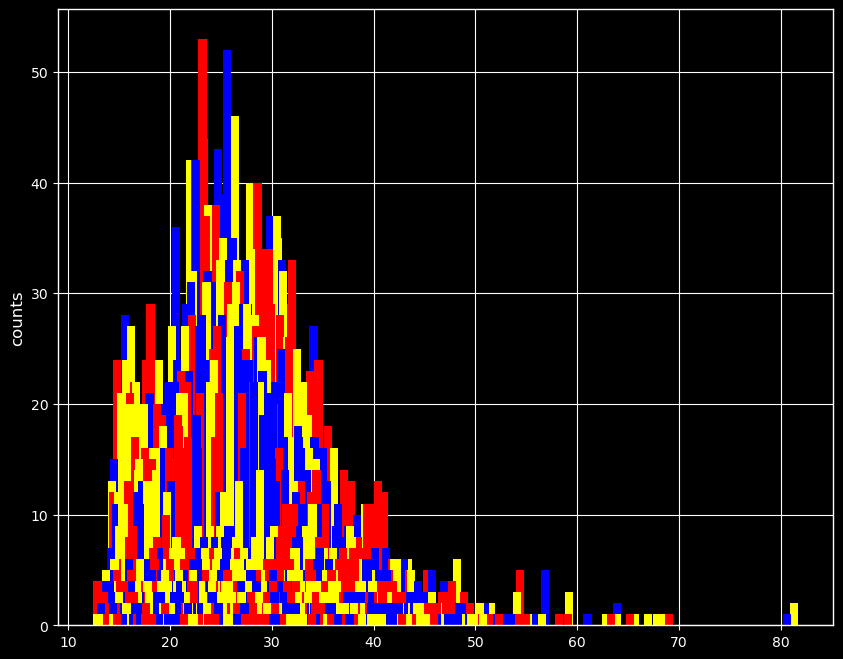

In [89]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8))                                  #change this to get different sized plots
plt.bar(list(counts.keys()),counts,color=['red','blue','yellow'])    #change colors here to get somthing better -> (0,0,0)=black or (1.0,1.0,1.0)= white scaled RGB
plt.ylabel('counts')

In [161]:
counts = data[:]['Race1'].value_counts()
counts

Race1
White       6372
Black       1197
Mexican     1015
Other        806
Hispanic     610
Name: count, dtype: int64

<BarContainer object of 5 artists>

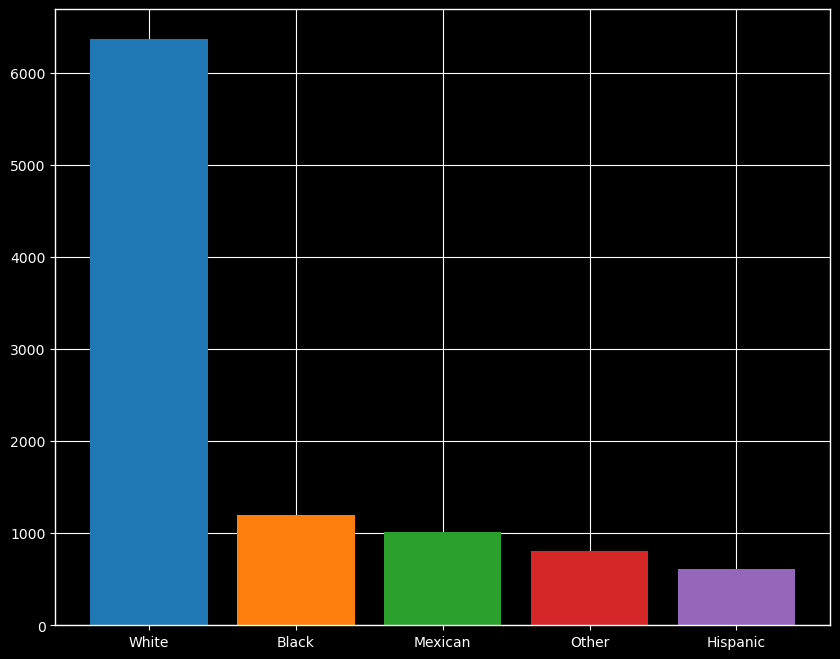

In [162]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8)) 
plt.bar(list(counts.keys()),counts,color=mcolors.TABLEAU_COLORS)

#### Scatter Plots (Good for 2D Numeric)

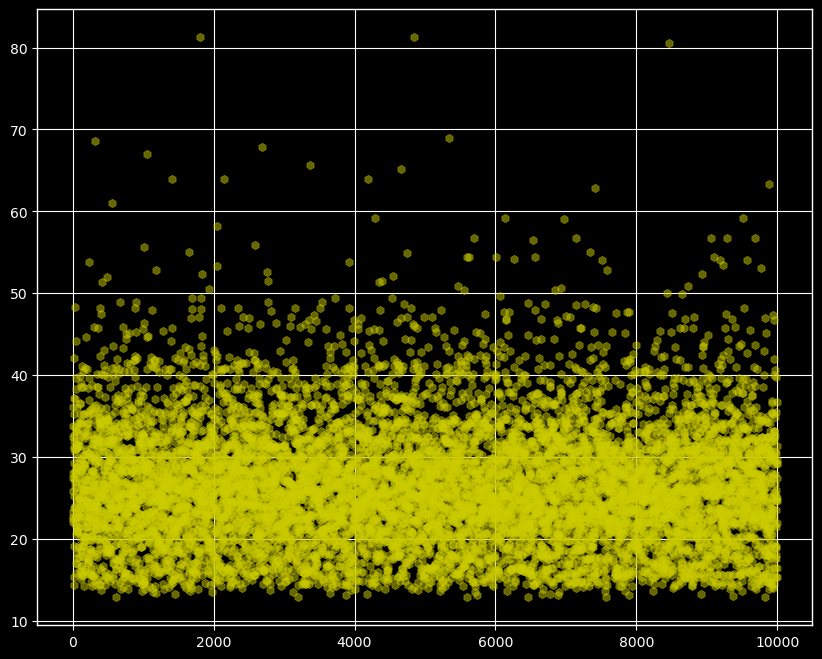

In [163]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8)) 
plt.scatter(range(0,len(data),1),data[:]['BMI'],color=(0.8,0.8,0.0,0.5),marker='h') #not great for looking at single variables

#### Histogram (Bar Plot with Binned Numeric Axis)

In [93]:
H = np.histogram(data[:]['BMI'],bins=[0,10,20,30,40,50,60,70,80,90])

<BarContainer object of 9 artists>

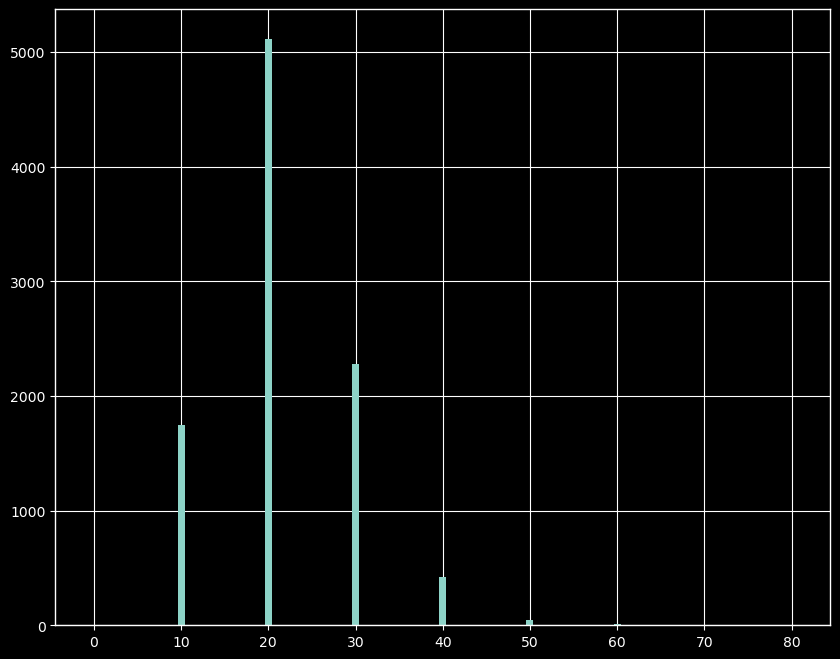

In [94]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8))
plt.bar(H[1][:-1],H[0])

(array([1.651e+03, 3.517e+03, 2.903e+03, 1.112e+03, 3.350e+02, 7.600e+01,
        2.500e+01, 9.000e+00, 3.000e+00, 3.000e+00]),
 array([12.88 , 19.717, 26.554, 33.391, 40.228, 47.065, 53.902, 60.739,
        67.576, 74.413, 81.25 ]),
 <BarContainer object of 10 artists>)

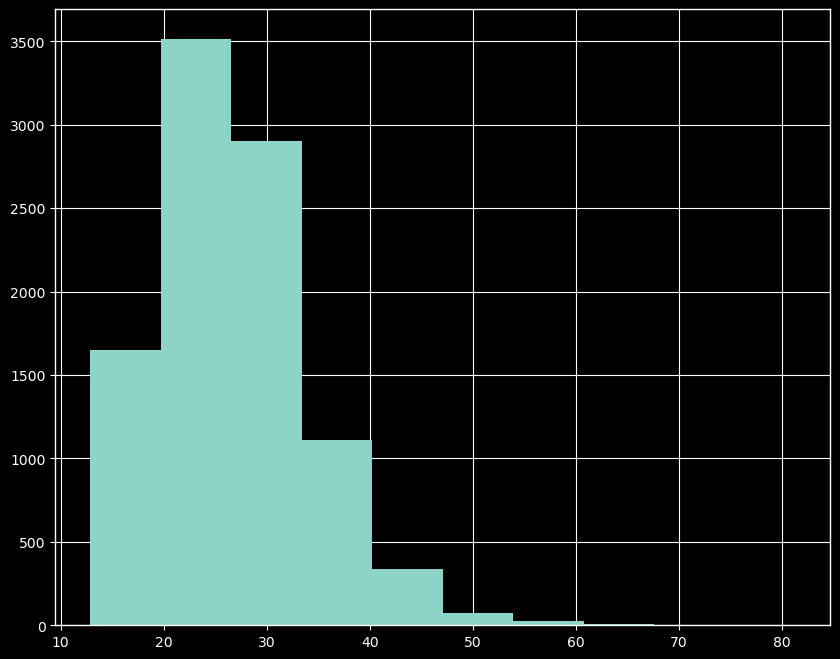

In [95]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8))
plt.hist(data[:]['BMI'])         #or just use the built-in matplotlib histogram for visualizing

#### Boxplot (Shows Quartiles of the Dataset)

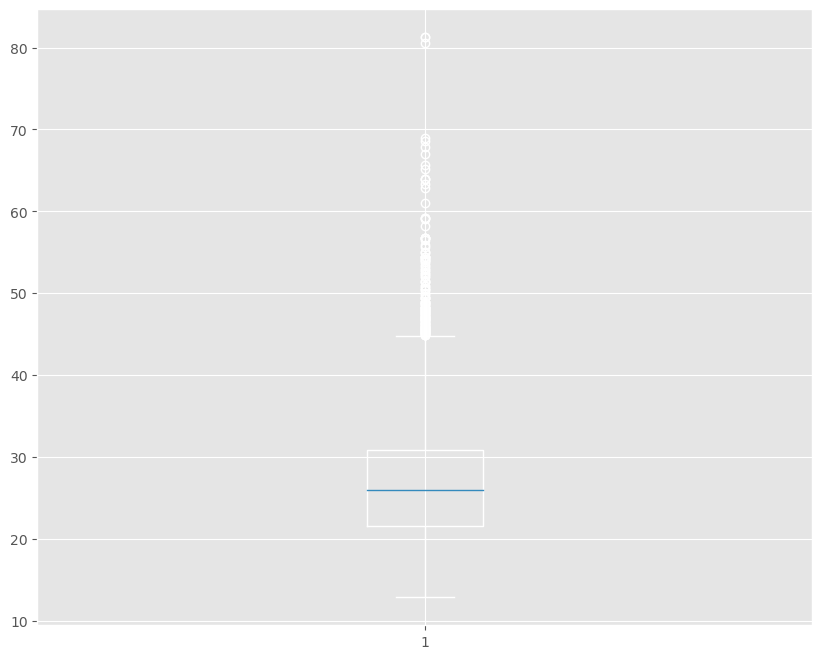

In [96]:
plt.style.use('ggplot')
plt.figure(figsize=(10,8))
d = np.asarray(data[:]['BMI']) #filter out the NaN values and plot a bar plot
plt.boxplot(d[~np.isnan(d)])
plt.show()

#### Violinplot (Shows distribution shape of the Dataset)

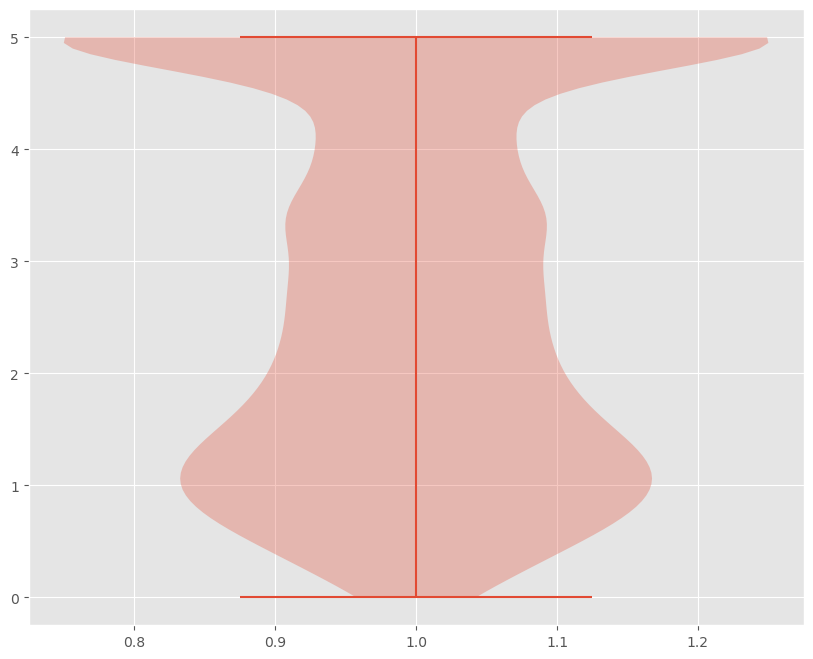

In [97]:
plt.style.use('ggplot')
plt.figure(figsize=(10,8))
d = np.asarray(data[:]['Poverty']) #filter out the NaN values and plot a bar plot
plt.violinplot(d[~np.isnan(d)])
plt.show()

In [98]:
#pick on of your own to explore from the following:
data.columns

Index(['SurveyYr', 'ID', 'Gender', 'Age', 'AgeDecade', 'AgeMonths', 'Race1',
       'Race3', 'Education', 'MaritalStatus', 'HHIncome', 'HHIncomeMid',
       'Poverty', 'HomeRooms', 'HomeOwn', 'Work', 'Weight', 'Length',
       'HeadCirc', 'Height', 'BMI', 'BMICatUnder20yrs', 'BMI_WHO', 'Pulse',
       'BPSysAve', 'BPDiaAve', 'BPSys1', 'BPDia1', 'BPSys2', 'BPDia2',
       'BPSys3', 'BPDia3', 'Testosterone', 'DirectChol', 'TotChol',
       'UrineVol1', 'UrineFlow1', 'UrineVol2', 'UrineFlow2', 'Diabetes',
       'DiabetesAge', 'HealthGen', 'DaysPhysHlthBad', 'DaysMentHlthBad',
       'LittleInterest', 'Depressed', 'nPregnancies', 'nBabies', 'Age1stBaby',
       'SleepHrsNight', 'SleepTrouble', 'PhysActive', 'PhysActiveDays',
       'TVHrsDay', 'CompHrsDay', 'TVHrsDayChild', 'CompHrsDayChild',
       'Alcohol12PlusYr', 'AlcoholDay', 'AlcoholYear', 'SmokeNow', 'Smoke100',
       'Smoke100n', 'SmokeAge', 'Marijuana', 'AgeFirstMarij', 'RegularMarij',
       'AgeRegMarij', 'HardDrugs', 'SexEve

In [121]:
#transformation of catagorical variables is required for some techniques, but others make use of those qualities
data[data[:]['SmokeNow']=='Yes'].head() #give me the first 10 rows that have Gender=='male'

,SurveyYr,ID,Gender,Age,AgeDecade,AgeMonths,Race1,Race3,Education,MaritalStatus,...,AgeFirstMarij,RegularMarij,AgeRegMarij,HardDrugs,SexEver,SexAge,SexNumPartnLife,SexNumPartYear,SameSex,SexOrientation
5,2009_10,56329,female,39,30-39,477.0,White,NaN,8thGrade,Married,...,15.0,Yes,23.0,No,Yes,15.0,15.0,1.0,No,Heterosexual
22,2009_10,56339,male,55,50-59,665.0,Black,NaN,SomeCollege,NaN,...,NaN,No,NaN,No,Yes,16.0,40.0,1.0,No,Heterosexual
23,2009_10,61052,male,47,40-49,565.0,White,NaN,SomeCollege,Divorced,...,15.0,No,NaN,No,Yes,18.0,10.0,3.0,No,Heterosexual
33,2009_10,57659,male,54,50-59,651.0,Other,NaN,CollegeGrad,Married,...,NaN,No,NaN,No,Yes,29.0,1.0,0.0,No,NaN
36,2009_10,58694,male,60,60-69,721.0,Black,NaN,8thGrade,Divorced,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
data[data[:]['SmokeNow']=='No'].tail() #give me the last 10 rows that have Gender=='female'

,SurveyYr,ID,Gender,Age,AgeDecade,AgeMonths,Race1,Race3,Education,MaritalStatus,...,AgeFirstMarij,RegularMarij,AgeRegMarij,HardDrugs,SexEver,SexAge,SexNumPartnLife,SexNumPartYear,SameSex,SexOrientation
9984,2011_12,64637,male,77,70+,NaN,Hispanic,Hispanic,9_11thGrade,Married,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9985,2011_12,65318,female,80,NaN,NaN,White,White,SomeCollege,Widowed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9987,2011_12,66568,female,52,50-59,NaN,White,White,CollegeGrad,Divorced,...,19.0,No,NaN,No,Yes,18.0,9.0,1.0,No,Heterosexual
9990,2011_12,71020,female,80,NaN,NaN,White,White,HighSchool,Widowed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9999,2011_12,62881,female,57,50-59,NaN,White,White,CollegeGrad,Married,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
data.dtypes #we can see Geneder is an object datatype (most likely string, right?)

SurveyYr               str
ID                   int64
Gender                 str
Age                  int64
AgeDecade              str
                    ...   
SexAge             float64
SexNumPartnLife    float64
SexNumPartYear     float64
SameSex                str
SexOrientation         str
Length: 75, dtype: object

In [129]:
data['SameSex'] = data['SameSex'].astype('category') #pandas way of coverting to categorical types
data.dtypes

SurveyYr                str
ID                    int64
Gender             category
Age                   int64
AgeDecade               str
                     ...   
SexAge              float64
SexNumPartnLife     float64
SexNumPartYear      float64
SameSex            category
SexOrientation          str
Length: 75, dtype: object

In [130]:
gender = data['SameSex'].cat.codes
gender

# data[:]['Gender'].value_counts()

0       0
1      -1
2      -1
3       0
4      -1
       ..
9995    0
9996    0
9997    0
9998    0
9999   -1
Length: 10000, dtype: int8

In [148]:
data['HardDrugs'] = data['HardDrugs'].astype('category')
data['HardDrugs'].cat.codes

0        697
1       1547
2         -1
3        649
4         -1
        ... 
9995    1224
9996     810
9997    1713
9998    1215
9999     846
Length: 10000, dtype: int16

<BarContainer object of 2 artists>

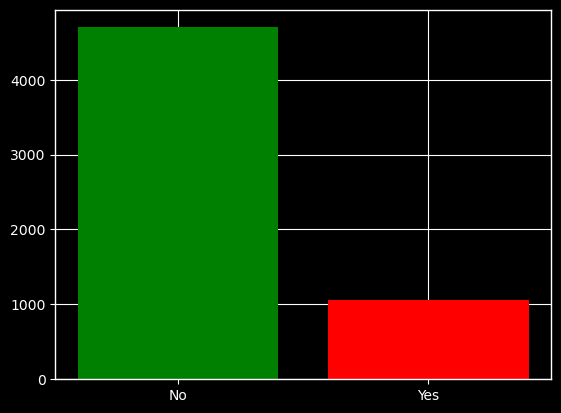

In [153]:
#put back the NaN into the -1 categories
hard = data['HardDrugs'].cat.codes
hard[hard==-1] = np.NaN
plt.bar(list(data['HardDrugs'].value_counts().keys()),data['HardDrugs'].value_counts(),color=['green','red'])
# plt.bar(['Yes','No'],hard.value_counts(),color=['green','red'])

In [137]:
np.median(data[:]['HardDrugs'])

TypeError: '<' not supported between instances of 'float' and 'str'

In [154]:
np.median(hard)

nan

In [155]:
np.median(hard[~np.isnan(hard)])

0.0

In [156]:
np.mean(hard[~np.isnan(hard)])

0.18473547267996532

#### Transformation of data domain

Sometimes it may be easier to visualize or find patterns in the data if you actually modify all the values in the columns using a function. For example we often can use an opposing function if our data looks like it is non-linear. Lets look at the Race1 again which seems to have a lot of the white value.

In [158]:
counts = np.log(data[:]['Race1'].value_counts())
counts

Race1
White       8.759669
Black       7.087574
Mexican     6.922644
Other       6.692084
Hispanic    6.413459
Name: count, dtype: float64

<BarContainer object of 5 artists>

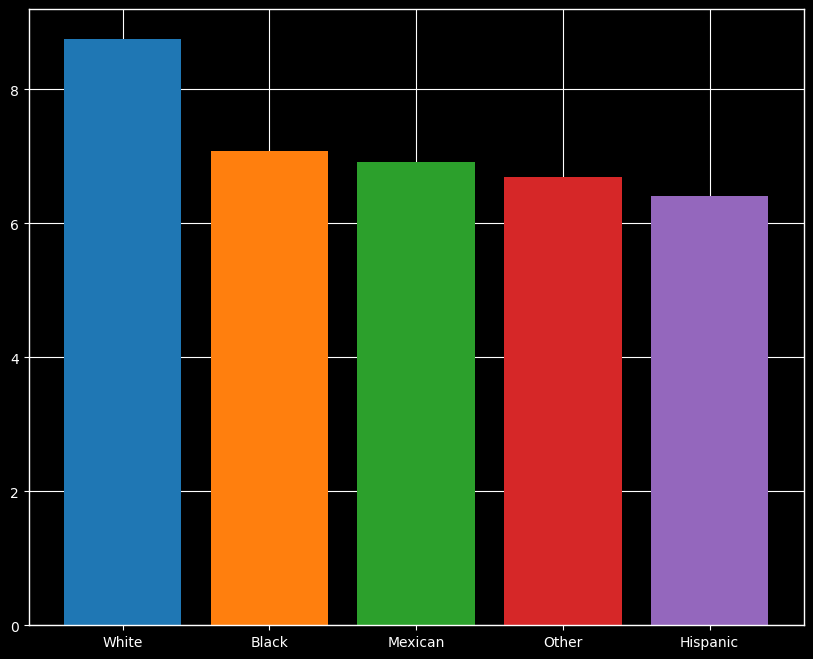

In [159]:
plt.style.use('dark_background')
plt.figure(figsize=(10,8)) 
plt.bar(list(counts.keys()),counts,color=mcolors.TABLEAU_COLORS)

This type of transformation can be used to find non-linear associations and is part of logistic regression and general linear modeling